In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from collections import Counter 
from wordcloud import WordCloud, STOPWORDS

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

Мои примечания 

Данные за 23 год

In [202]:
data = pd.read_parquet(r"data\train-00000-of-00001-49261e4e5a35a5a0.parquet", engine="fastparquet")
data.head()

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


In [203]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   address  500000 non-null  object
 1   name_ru  499030 non-null  object
 2   rating   500000 non-null  int64 
 3   rubrics  500000 non-null  object
 4   text     500000 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.1+ MB


In [204]:
data.isnull().sum()

address      0
name_ru    970
rating       0
rubrics      0
text         0
dtype: int64

In [205]:
print(data.duplicated().sum())
data = data.drop_duplicates()
print(data.duplicated().sum())

1
0


In [206]:
data["address"].nunique()

191925

In [207]:
data["address"].value_counts(ascending=False)

address
Москва, Ходынский бульвар, 4                                      340
Москва, проспект Андропова, 1                                     264
Москва, Пресненская набережная, 2                                 234
Москва, поселение Московский, Киевское шоссе, 23-й километр, 1    226
Санкт-Петербург, Приморский проспект, 72                          215
                                                                 ... 
Ставрополь, улица Горького, 57                                      1
Саратов, Астраханская улица, 1Е                                     1
Саратовская область, рабочий посёлок Озинки                         1
Великий Новгород, Городище, 19-й квартал                            1
Челябинск, улица Свободы, 2, корп. 5                                1
Name: count, Length: 191925, dtype: int64

In [208]:
data["name_ru"].nunique()

148456

In [209]:
data["name_ru"].value_counts(ascending=False)

name_ru
Пятёрочка            6030
Магнит               2611
Красное&Белое        1732
Wildberries          1698
Ozon                 1494
                     ... 
MyDomStroy              1
Foxy Nail               1
Шаурма 1001             1
Рюриково городище       1
6 Отметка               1
Name: count, Length: 148456, dtype: int64

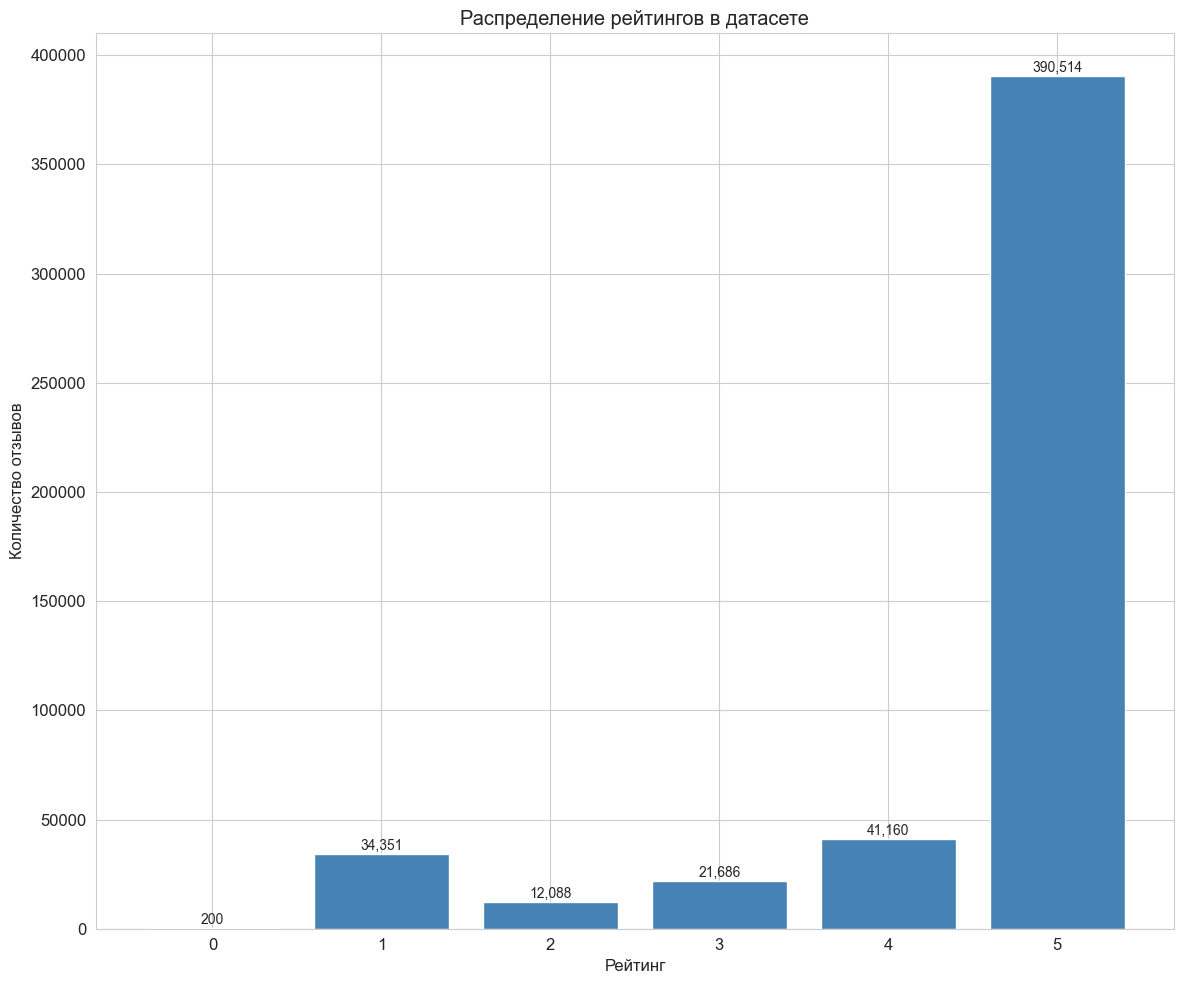

In [210]:
rating_counts = data["rating"].value_counts().sort_index()

plt.figure(figsize=(12, 10))
bars = plt.bar(rating_counts.index.astype(str), rating_counts.values, color="steelblue")
plt.xlabel("Рейтинг")
plt.ylabel("Количество отзывов")
plt.title("Распределение рейтингов в датасете")

for bar, count in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [211]:
# преоброзование целевой переменной (таргета)
def edit_target(rating):
    if rating >= 4:
        return 1
    if rating <= 2:
        return 0
    else:
        return -1
    
data["rating"] = data["rating"].map(edit_target)

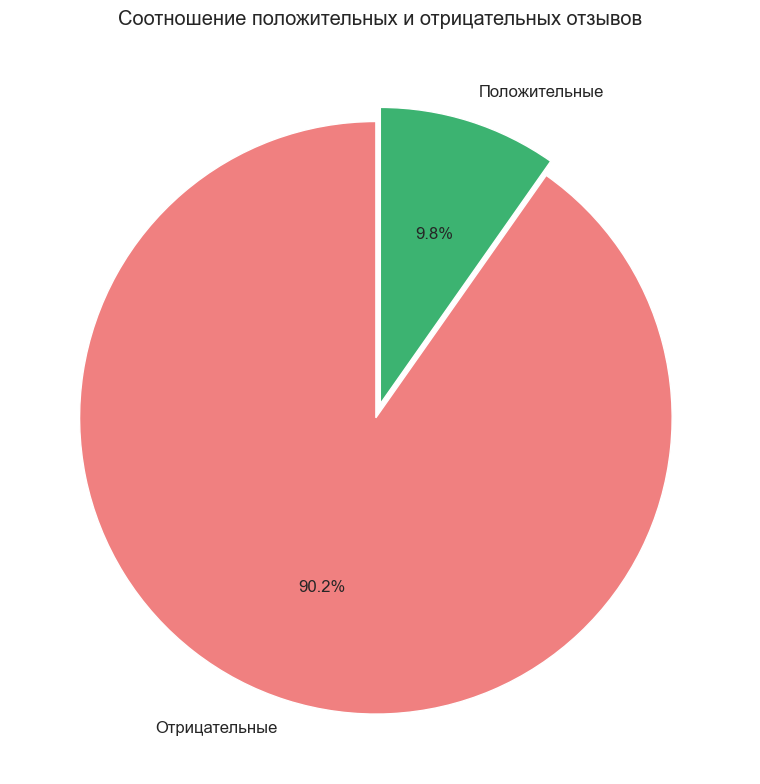

In [212]:
data_clean = data[data["rating"] != -1].copy()

sentiment_counts = data_clean["rating"].value_counts()
labels = ['Отрицательные', 'Положительные']
colors = ['lightcoral', 'mediumseagreen']

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, autopct="%1.1f%%",
        colors=colors, labels=labels,
        startangle=90, explode=(0.05, 0))
plt.title("Соотношение положительных и отрицательных отзывов");
plt.tight_layout()
plt.show()

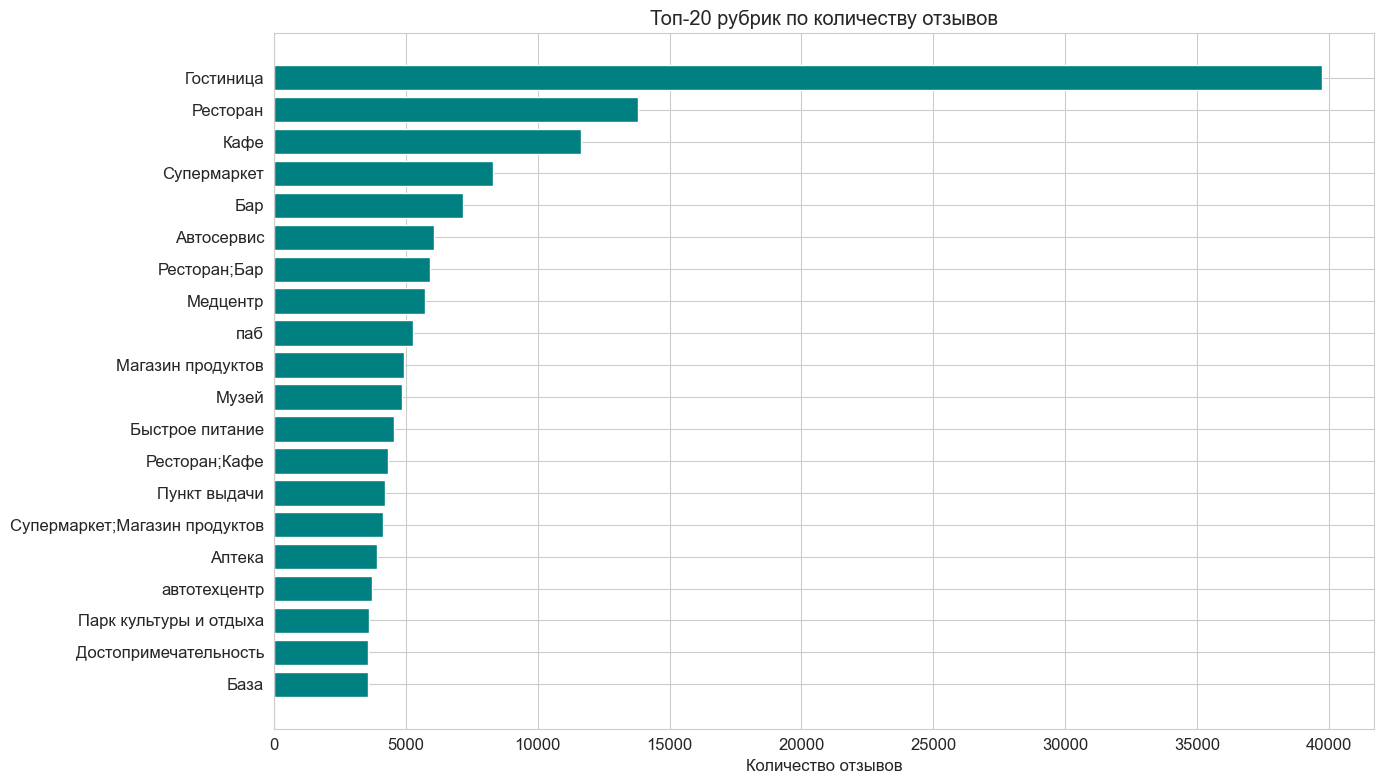

In [213]:
import ast

all_rubrics = []
for val in data_clean['rubrics'].dropna():
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                all_rubrics.extend(parsed)
        except:
            items = [x.strip() for x in val.split(',') if x.strip()]
            all_rubrics.extend(items)

rubric_counts = Counter(all_rubrics)
top_rubrics = rubric_counts.most_common(20)

rubrics = [item[0] for item in top_rubrics]
counts = [item[1] for item in top_rubrics]

plt.figure(figsize=(14, 8))
plt.barh(range(len(rubrics)), counts, color='teal')
plt.yticks(range(len(rubrics)), rubrics)
plt.xlabel('Количество отзывов')
plt.title('Топ-20 рубрик по количеству отзывов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

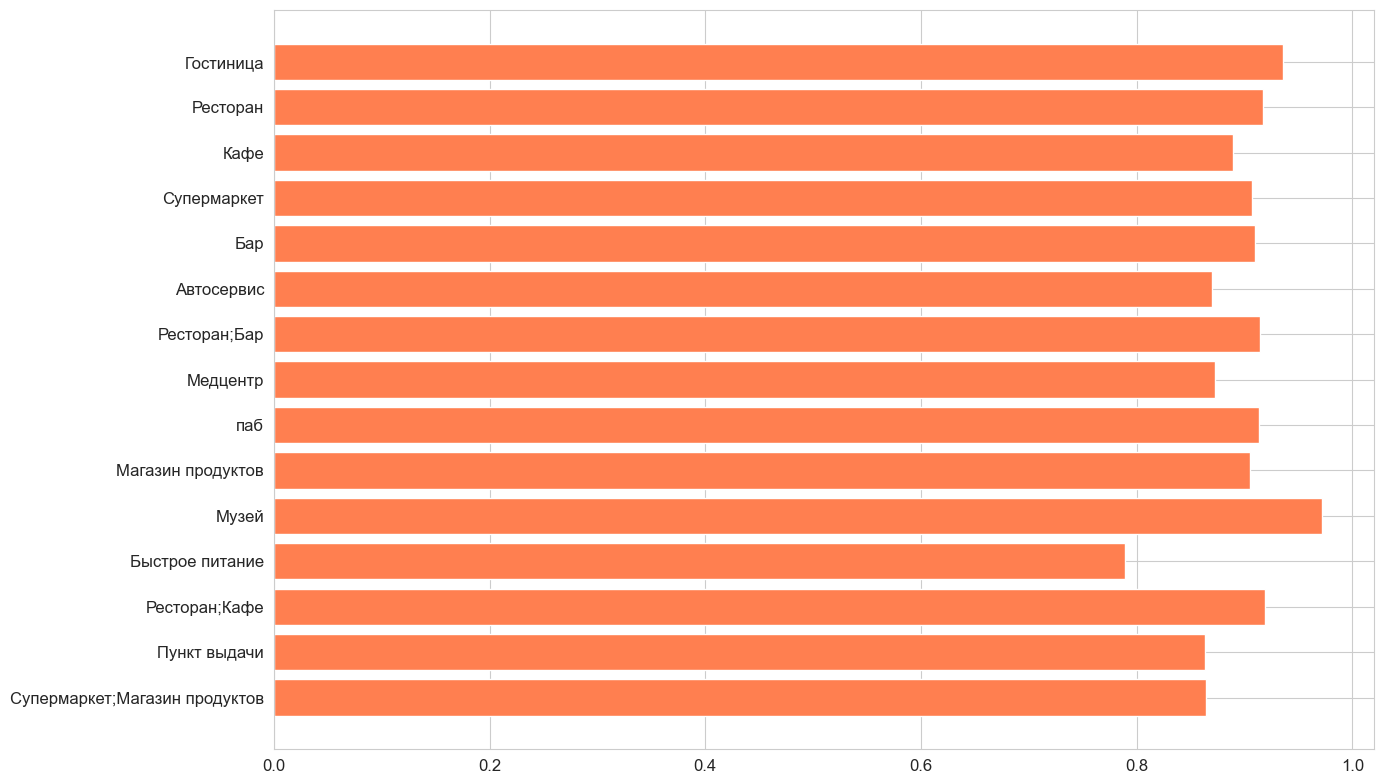

In [214]:
rubric_ratings = {}
for _, row in data_clean.iterrows():
    val = row['rubrics']
    if pd.isna(val): continue
    if isinstance(val, list):
        items = val
    elif isinstance(val, str):
        try:
            items = ast.literal_eval(val)
            if not isinstance(items, list): items = [val]
        except:
            items = [x.strip() for x in val.split(',') if x.strip()]
    else:
        continue
    for r in items:
        rubric_ratings.setdefault(r, []).append(row['rating'])

rubric_avg = {r: np.mean(v) for r, v in rubric_ratings.items()}
top = sorted(rubric_avg.items(), key=lambda x: len(rubric_ratings[x[0]]), reverse=True)[:15]
r, a = zip(*top)

plt.figure(figsize=(14, 8))
plt.barh(range(len(r)), a, color='coral')
plt.yticks(range(len(r)), r)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

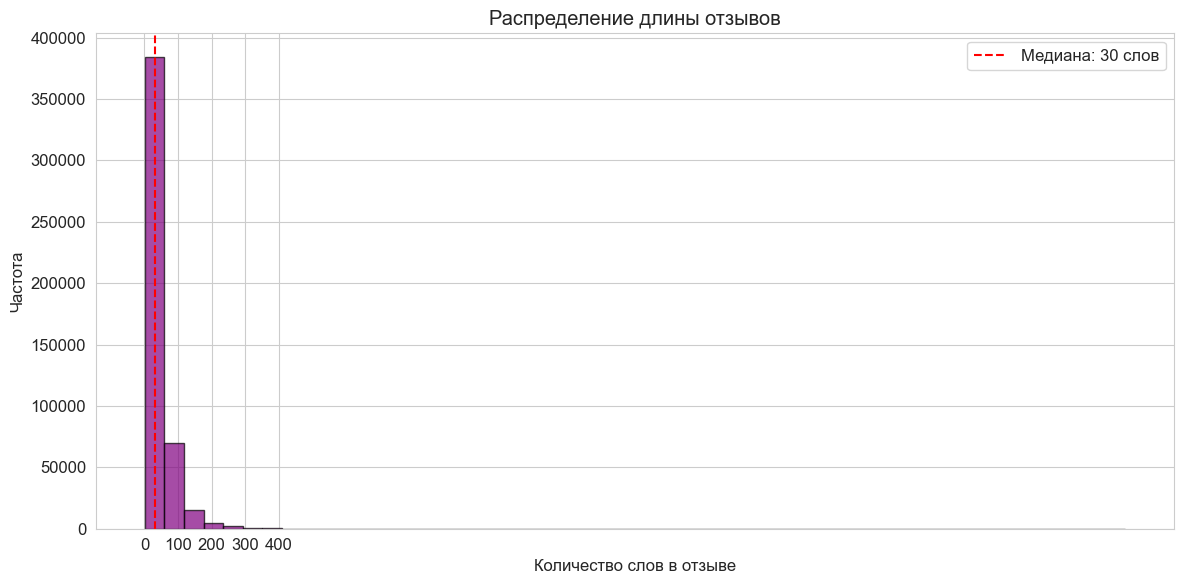

<Figure size 1000x600 with 0 Axes>

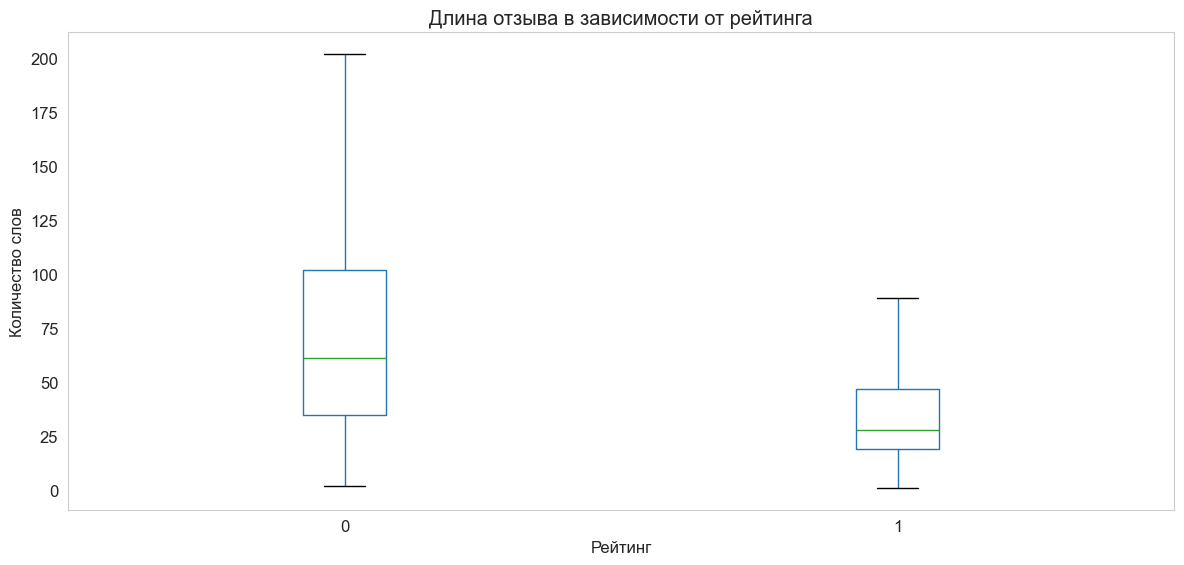

In [215]:
data_clean['text_length'] = data_clean['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
plt.hist(data_clean['text_length'], bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(data_clean['text_length'].median(), color='red', linestyle='--', 
            label=f"Медиана: {data_clean['text_length'].median():.0f} слов")
max_len = data_clean['text_length'].max()
plt.xticks(np.arange(0, 500, 100))
plt.xlabel('Количество слов в отзыве')
plt.ylabel('Частота')
plt.title('Распределение длины отзывов')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
data_clean.boxplot(column='text_length', by='rating', grid=False, showfliers=False)
plt.xlabel('Рейтинг')
plt.ylabel('Количество слов')
plt.title('Длина отзыва в зависимости от рейтинга')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [216]:
data["address"]

0         Екатеринбург, ул. Московская / ул. Волгоградск...
1         Московская область, Электросталь, проспект Лен...
2         Краснодар, Прикубанский внутригородской округ,...
3          Санкт-Петербург, проспект Энгельса, 111, корп. 1
4                         Тверь, Волоколамский проспект, 39
                                ...                        
499995    Москва, Южный административный округ, район Би...
499996    Москва, Южный административный округ, район Би...
499997             Новосибирск, Коммунистическая улица, 48А
499998            Астраханская область, Харабалинский район
499999            Астраханская область, Харабалинский район
Name: address, Length: 499999, dtype: object

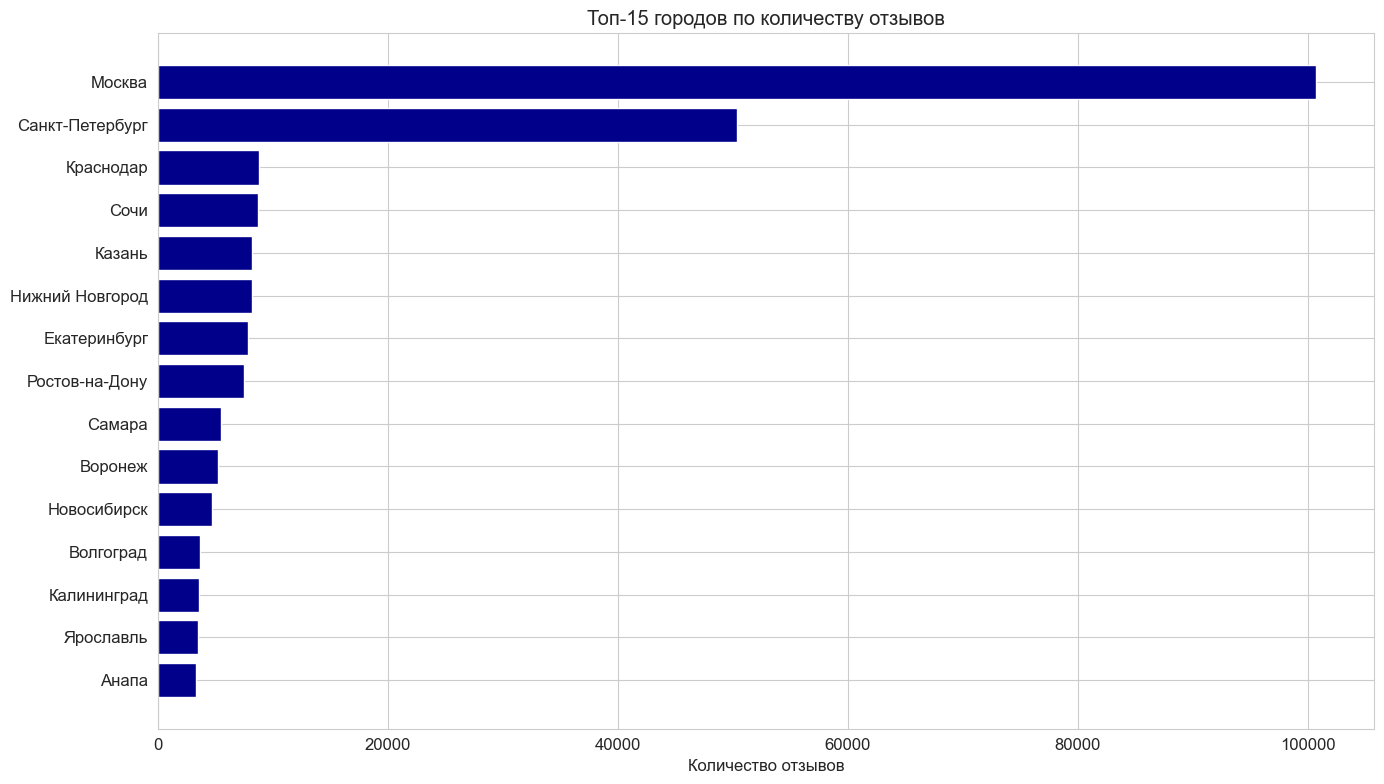

In [217]:
def extract_city(address):
    if pd.isna(address):
        return 'Не указан'
    parts = [p.strip() for p in str(address).split(',')]
    if not parts:
        return 'Не указан'
    region_keywords = ['область', 'край', 'республика', 'автономный округ', 'ао']
    first_lower = parts[0].lower()
    if any(kw in first_lower for kw in region_keywords) and len(parts) >= 2:
        return parts[1]
    return parts[0]

data_clean['city'] = data_clean['address'].apply(extract_city)

city_counts = data_clean['city'].value_counts().head(15)

plt.figure(figsize=(14, 8))
plt.barh(range(len(city_counts)), city_counts.values, color='darkblue')
plt.yticks(range(len(city_counts)), city_counts.index)
plt.xlabel('Количество отзывов')
plt.title('Топ-15 городов по количеству отзывов')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('plots/07_top_cities.png', dpi=150)
plt.show()

In [218]:
# предобработка текста
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stopwords_ru = set(stopwords.words('russian'))

custom_ru = {
    'это', 'что', 'был', 'была', 'было', 'весь', 'свой', 'который', 'очень', 'просто',
    'все', 'ещё', 'уже', 'тоже', 'может', 'будет', 'есть', 'нет', 'да', 'для', 'как', 'так',
    'меня', 'мне', 'себя', 'свою', 'свои', 'под', 'над', 'при', 'без', 'или', 'на', 'в', 'с',
    'по', 'из', 'от', 'о', 'к', 'у', 'за', 'до', 'во', 'со', 'об', 'не', 'но', 'а', 'и', 'то',
    'он', 'вас', 'теперь', 'них', 'вообще', 'этом', 'его', 'n', 'же', 'нас', 'вот', 'их',
    'тут', 'еще', 'даже', 'когда', 'ну', 'только', 'поэтому', 'надо', 'ней', 
    'хотя', 'если', 'конечно', 'где', 'один', 'том', 'вы', 'совсем', 'чтобы', 'именно', 'ее', 'чем', 
    'этого', 'раз', 'много', 'ним', 'кто', 'всех', 'были', 'сразу', 'потому', 'видимо', 'им', 
    'почему', 'потом', 'нам', 'какой', 'про', 'общем', 'ли', 'ни', 'ничего', 'всё', 
    'всегда', 'вам', 'там', 'сказали', 'мастер', 'я', 'мы', 'они', 'бы', 'она', 'nB', 'т', 'её', 'после'
}

stopwords_ru.update(custom_ru)

print(f"Размер итогого словаря стоп слов: {len(stopwords_ru)}")

Размер итогого словаря стоп слов: 175


In [219]:
positive_text = ' '.join(data_clean[data_clean['rating'] == 1]['text'].dropna().astype(str))
negative_text = ' '.join(data_clean[data_clean['rating'] == 0]['text'].dropna().astype(str))

# # Положительные
# wordcloud_pos = WordCloud(width=800, height=400, background_color='white',
#                           stopwords=stopwords_ru, max_words=100, colormap='Greens',
#                           random_state=42).generate(positive_text)
# plt.figure(figsize=(16, 8))
# plt.imshow(wordcloud_pos, interpolation='bilinear')
# plt.axis('off')
# plt.title('Самые частые слова в ПОЛОЖИТЕЛЬНЫХ отзывах', fontsize=16)
# plt.tight_layout()
# plt.show()

# # Отрицательные
# wordcloud_neg = WordCloud(width=800, height=400, background_color='white',
#                           stopwords=stopwords_ru, max_words=100, colormap='Reds',
#                           random_state=42).generate(negative_text)
# plt.figure(figsize=(16, 8))
# plt.imshow(wordcloud_neg, interpolation='bilinear')
# plt.axis('off')
# plt.title('Самые частые слова в ОТРИЦАТЕЛЬНЫХ отзывах', fontsize=16)
# plt.tight_layout()
# plt.show()

In [223]:
# геокодирование
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

city_stats = data_clean.groupby(by="city").agg(
    avg_ratings=("rating", "mean"),
    count_ratings=("rating", "count")
).reset_index()

city_stats = city_stats[city_stats["count_ratings"] >= 100]

print(f"Количество городов в агрегированной таблице: {city_stats.shape[0]}")
city_stats.head()

Количество городов в агрегированной таблице: 386


,city,avg_ratings,count_ratings
253,Абакан,0.869779,407
270,Азов,0.889908,218
271,Азовский район,0.926829,123
272,Аксай,0.902098,286
273,Аксайский район,0.940299,268


In [225]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

geolocator = Nominatim(user_agent="diplom_geo_ratings")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coordinates(city_name):
    try:
        location = geocode(f"{city_name}, Россия")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except:
        return None, None 
    
city_stats["lat"], city_stats["lon"] = zip(*city_stats["city"].apply(get_coordinates))
city_stats_geo = city_stats.dropna(subset=['lat', 'lon'])
print(f"Городов с координатами: {len(city_stats_geo)}")

Городов с координатами: 372


In [234]:
import plotly.express as px

city_stats_geo['avg_negative'] = 1 - city_stats_geo['avg_ratings']

city_map = px.scatter_mapbox(
    city_stats_geo,
    lat="latitude",
    lon="longitude",
    color="avg_negative",               # теперь красим по доле негатива
    size="count_ratings",
    color_continuous_scale='Reds',      # только красная шкала
    range_color=(0, 0.3),               # ограничим сверху, чтобы был контраст
    hover_name="city",
    hover_data={'avg_ratings': ':.1%', 'avg_negative': ':.1%', 'count_ratings': ':,.0f'},
    zoom=3,
    center={'lat': 55.0, 'lon': 100.0},
    title="Доля отрицательных отзывов по городам России",
    mapbox_style="carto-positron",
    height=1000
)

city_map.show()

C:\Users\79654\AppData\Local\Temp\ipykernel_19508\2872940893.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  city_map = px.scatter_mapbox(
